**IBM HR Analytics Employee Attrition & Performance Analysis Report**

Based on common analysis of the IBM HR Analytics Employee Attrition & Performance dataset from Kaggle, the key drivers of employee attrition have been identified. The overall attrition rate in the dataset is approximately 16%, and the analysis reveals several factors associated with higher turnover.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


**Data Exploration**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
counts= df["Attrition"].value_counts()    # 237 people have left the organisation out of 1470
counts

Attrition
No     1233
Yes     237
Name: count, dtype: int64

**Active V/s Attrition** 

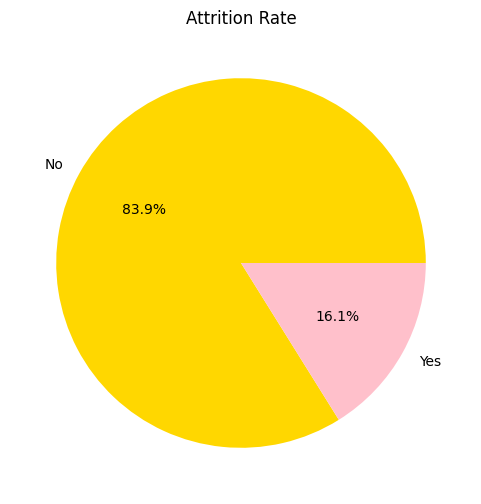

In [6]:
plt.figure(figsize = (6,6))
plt.pie(counts, labels= counts.index ,autopct="%1.1f%%", colors = ['Gold','Pink'])
plt.title("Attrition Rate")
plt.show()

**Attrition By Age**

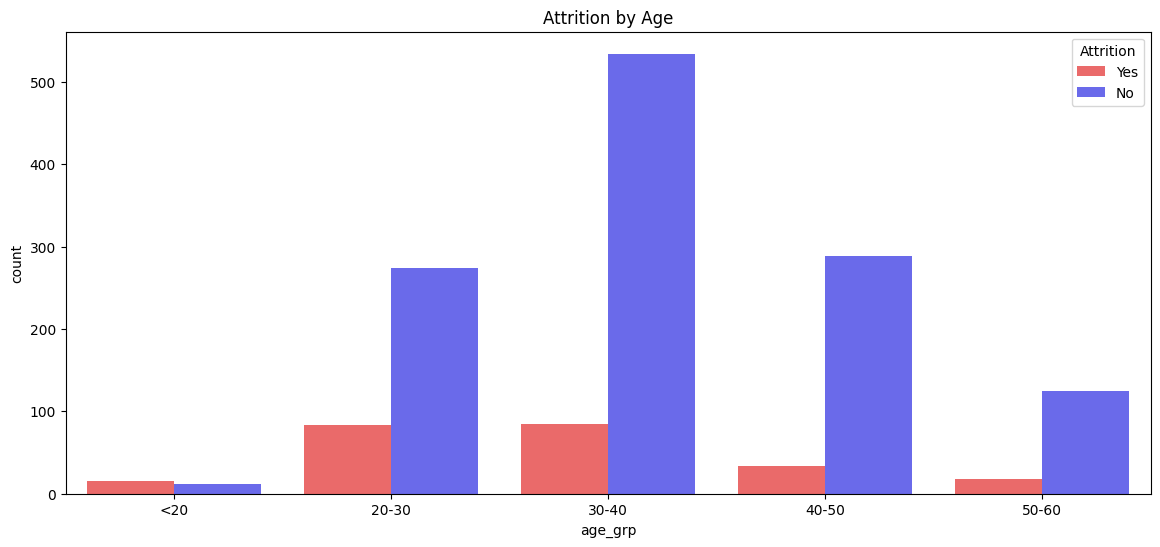

In [7]:
bins =[0,20,30,40,50,60]
labels = ['<20','20-30','30-40','40-50','50-60'] # for grouping age
df["age_grp"]= pd.cut(df['Age'], bins=bins, labels=labels,include_lowest=True )
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x="age_grp", hue='Attrition', palette='seismic_r')
plt.title('Attrition by Age')
plt.show()
# Employees in the age group of 20-40 are ore likely to leave the Organization

**Employee Attrition by Department**

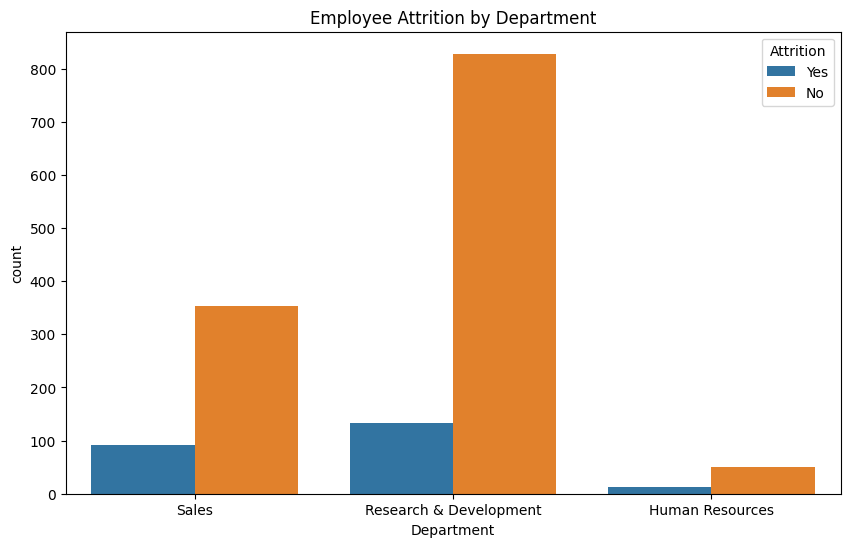

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Employee Attrition by Department')    
plt.show()
 # Research & Training dept is having high rate of attrition. followed by sales

**WorkLifeBalance vs. Attrition**

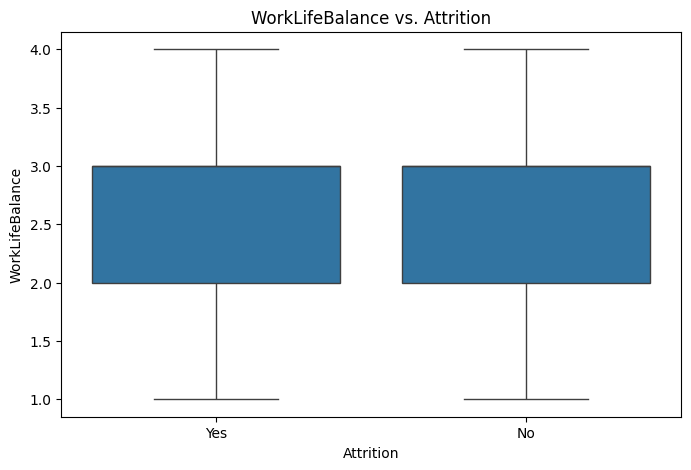

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='WorkLifeBalance', data=df)
plt.title('WorkLifeBalance vs. Attrition')
plt.show()
# Chart suggest a correlation where a lower perceived work life balance is associated with a higher likelyhood of employee attrition.

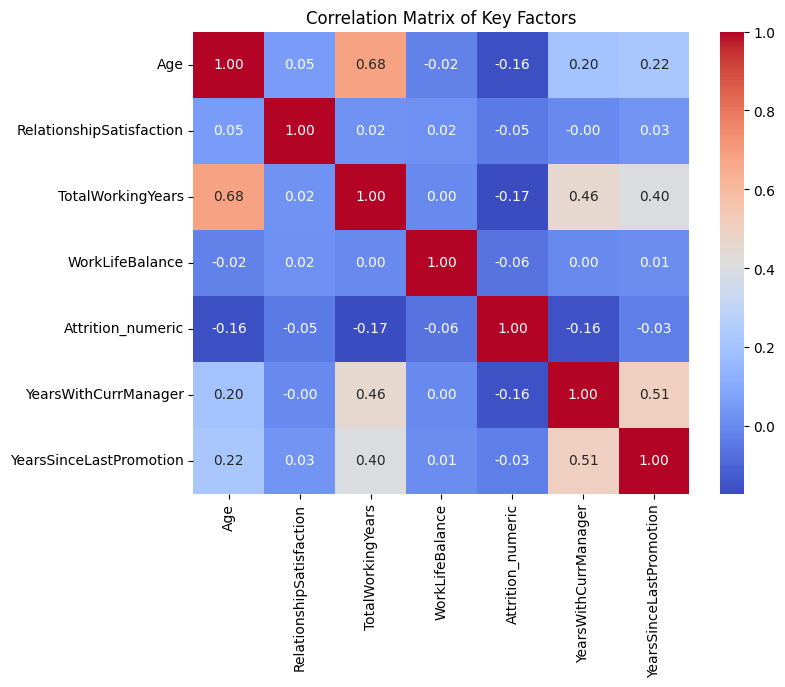

In [10]:
# First, ensure 'Attrition' is numerical (e.g., 0 for No, 1 for Yes)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Attrition_numeric'] = le.fit_transform(df['Attrition'])

# Select relevant numerical columns and plot the heatmap
numerical_cols = ['Age', 'RelationshipSatisfaction', 'TotalWorkingYears', 'WorkLifeBalance', 'Attrition_numeric','YearsWithCurrManager','YearsSinceLastPromotion']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Factors')
plt.show()

**Chart suggest**:
With **age** employees have more toal year of experience.

Those with more **no of years with managers**, have a higher no of experience since their last promotion.

**Younger employees** and those with **fewer working experience** are slightly more likely to leave the company. 

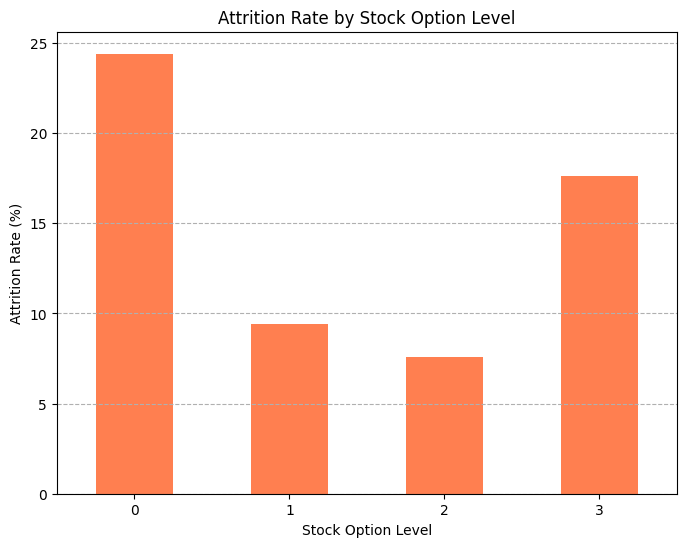

In [11]:

# Assuming your DataFrame is named 'df'
# 'StockOptionLevel' is an integer/category column (e.g., 0, 1, 2, 3)
# 'Attrition' is a categorical column with values 'Yes' and 'No'

# 1. Calculate the attrition rate per Stock Option Level
# Create a cross-tabulation table of counts
attrition_crosstab = pd.crosstab(df['StockOptionLevel'], df['Attrition'])

# Calculate the attrition rate (percentage of "Yes" within each level)
# Normalize across each row (index=0) and select the 'Yes' column
attrition_rate = attrition_crosstab.div(attrition_crosstab.sum(axis=1), axis=0)['Yes'] * 100

# 2. Plot the results as a bar chart
# The pandas plot function works great with matplotlib underneath
plt.figure(figsize=(8, 6)) # Optional: adjust figure size
attrition_rate.plot.bar(color='coral')

# Add labels and title for clarity
plt.title('Attrition Rate by Stock Option Level')
plt.xlabel('Stock Option Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0) # Keep labels horizontal for readability
plt.grid(axis='y', linestyle='--') # Add a horizontal grid

# Display the chart
plt.show()

In [12]:
Data suggest that Level1 and Level2 are sweet spot for retention.
                                                  
Proving stock option at Level1-3 drastically reduces attrition compared to Level 0.
    
Spike at Level 3 indicate that employee at higher seniority or equity levels may get recruited by competitors
                                                  

SyntaxError: invalid syntax (3037558543.py, line 1)

In [ ]:
# 2. Visualize Promotion & Attrition
# Set up the plot
plt.figure(figsize=(12, 6))

# Plotting YearsSinceLastPromotion vs Attrition
sns.barplot(x='YearsSinceLastPromotion', y='YearsSinceLastPromotion', hue='Attrition', 
            data=df, estimator=lambda x: len(x) / len(df) * 100)

plt.title('Attrition Rate by Years Since Last Promotion')
plt.ylabel('Percentage of Employees')
plt.xlabel('Years Since Last Promotion')
plt.show()

# Higher risk occuring immediately after a promotion or withinn the first year

In [ ]:
# 3. Bar Plot: Job Level vs Average Income
plt.figure(figsize=(10, 6))
sns.barplot(x='JobLevel', y='MonthlyIncome', hue='Attrition', data=df)
plt.title('Average Monthly Income by Job Level and Attrition')
plt.show()
# Data suggest that lower monthly income, relative to those in the same role who stayed, is associated with hgher likelyhood of attrition

**Key Findings from Attrition Analysis**:

**Job Satisfaction and Work-Life Balance**: Employees with low job satisfaction or a poor work-life balance are significantly more likely to leave.

**Lower monthly income** is associated with higher attrition rates, especially among younger employees.

A significant drop in attrition is observed among employees who receive **stock options**

**Employees receiving the lowest salary hikes** also tend to leave more often. Employees working overtime have a higher attrition rate compared to those who do not. 

**Delayed promotions** (longer years since last promotion) may increase attrition.

**Recommendations**
Based on these insights, the following strategic recommendations can help reduce employee turnover:

**Revise Compensation and Benefits**: Ensure fair pay structures, particularly for lower-income and early-career employees. Re-evaluate stock option plans as they show a strong link to retention.
**Improve Work-Life Balance**: Address overtime issues and explore more flexible schedules or reduced stress initiatives to enhance employee well-being.

**Enhance Career Development**: Implement stronger onboarding programs and provide clear growth opportunities and regular feedback, especially for at-risk roles like Sales and Research Department
**Proactive Retention Programs**: Use the data to develop predictive models that identify high-risk employees early, allowing for targeted interventions.
**Boost Engagement**: Foster a better work environment and provide adequate training to increase job involvement and satisfaction.